In [1]:
import os
import numpy as np
from vit_keras import vit
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model, model_from_json
from tensorflow.keras import optimizers

os.environ["CUDA_VISIBLE_DEVICES"]= ""

2025-01-27 10:56:43.258968: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-27 10:56:43.368689: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-27 10:56:43.851025: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/home/kannika/miniconda3/envs/AI/lib/
2025-01-27 10:56:43.851086: W tensorflow/compile

## Load ViTL-32 : Train on USAI 15AB Unbalanced Dataset

In [2]:
model_dir = '/media/tohn/HDD2/Model_unlearn/Models_USAI/ViTModel/ViTorigin_USAI/R1_unbalanced/exp1/models/modelVITL32_USAI15ab-R1_unbalanced.h5'
model = load_model(model_dir)
height = width = model.input_shape[1]
print(height, width)

2025-01-27 10:56:47.911124: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:267] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-01-27 10:56:47.911181: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:169] retrieving CUDA diagnostic information for host: USAI
2025-01-27 10:56:47.911193: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:176] hostname: USAI
2025-01-27 10:56:47.911367: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:200] libcuda reported version is: 510.47.3
2025-01-27 10:56:47.911403: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:204] kernel reported version is: 510.47.3
2025-01-27 10:56:47.911414: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:310] kernel version seems to match DSO: 510.47.3
2025-01-27 10:56:47.911907: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neu

384 384


In [3]:
model.summary()

Model: "ViT_USAI"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 384, 384, 3)]     0         
                                                                 
 embedding (Conv2D)          (None, 12, 12, 1024)      3146752   
                                                                 
 reshape (Reshape)           (None, 144, 1024)         0         
                                                                 
 class_token (ClassToken)    (None, 145, 1024)         1024      
                                                                 
 Transformer/posembed_input   (None, 145, 1024)        148480    
 (AddPositionEmbs)                                               
                                                                 
 Transformer/encoderblock_0   ((None, 145, 1024),      12596224  
 (TransformerBlock)           (None, 16, None, None))     

In [4]:
# validation
import pandas as pd
base_dir = '/media/tohn/SSD/Images/Image1'
dataframe = pd.read_csv( '/media/tohn/HDD/VISION_dataset/Valdf_fold3_v2.csv')#แก้
validation_dir = os.path.join(base_dir, 'test')

#Train
train_df = pd.read_csv( '/media/tohn/HDD/VISION_dataset/Traindf_fold4_8_v2.csv')#แก้
base_dir = '/media/tohn/SSD/Images/Image1'
os.chdir(base_dir)
train_dir = os.path.join(base_dir, 'train')

In [5]:
len(set(dataframe['Sub_class_New']))

15

In [6]:
import pandas as pd
df0 = pd.read_csv('/media/tohn/HDD/VISION_dataset/Testdf_fold1_2_v1.csv')
print(df0 .shape)
dataframe = df0[(df0['Path Crop']!='None' )&(df0['Path Crop']!='Nan')]
print(dataframe.shape)
# print('Normal: ',dataframe[dataframe['Class']=='Normal'].shape)
# print('Abnormal: ',dataframe[dataframe['Class']=='Abnormal'].shape)
dataframe.head(5)

(1312, 27)
(1312, 27)


,Unnamed: 0,Case,Abs Position,Sub Position,Class,Path Full,Path Crop,Views,fold,15AB,...,Rwidth,Rheight,Sub_class_New,tag_AjNit,tag_AjWan,Test150,Spilt,Sub_Position_New,filename,Sub_Position_Label
0,111,40,P1,P1,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,0.513514,0.346614,AB01,NaN,NaN,False,Test,P1,AB01 P1 C040.JPG,P1
1,112,40,P2,P2,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,0.560377,0.428287,AB01,NaN,NaN,False,Test,P2,AB01 P2 C040.JPG,P2
2,113,40,P4,P41,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,0.667984,0.711155,AB01,NaN,NaN,False,Test,P4,AB01 P4-1 C040.JPG,P4
3,114,40,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,2,MildFattyLiver,...,0.690385,0.653386,AB01,NaN,NaN,False,Test,P6,AB01 P5-1 C040.JPG,P6
4,115,40,P3,P31,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,0.672515,0.625498,AB01,NaN,NaN,False,Test,P3,AB01 P3-1 C040.JPG,P3


In [7]:
batch_size = 64
epochs = 10

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
      rescale=1./255,
      rotation_range=30,
      width_shift_range=0.2,
      height_shift_range=0.2,
      brightness_range=[0.5,1.5],
      shear_range=0.4,
      zoom_range=0.2,
      horizontal_flip=False,
      fill_mode='nearest')

train_generator = train_datagen.flow_from_dataframe(
        dataframe = dataframe,
        directory = train_dir,
        x_col = 'Path Crop',
        y_col = 'Sub_class_New',
        target_size = (height, width),
        batch_size=batch_size,
        color_mode= 'rgb',
        class_mode='categorical')

#label
labels = (train_generator.class_indices)
labels = dict((v,k.replace("C","")) for k,v in labels.items())
print(labels)

Found 1312 validated image filenames belonging to 15 classes.
{0: 'AB01', 1: 'AB02', 2: 'AB03', 3: 'AB04', 4: 'AB05', 5: 'AB06', 6: 'AB07', 7: 'AB081', 8: 'AB082', 9: 'AB083', 10: 'AB09', 11: 'AB10', 12: 'AB11', 13: 'AB12', 14: 'Normal'}


# Prediction

In [8]:
from tensorflow.keras.preprocessing import image
def predict_image(img_path):
    # Read the image and resize it
    img = image.load_img(img_path, target_size=(height, width))
    # Convert it to a Numpy array with target shape.
    x = image.img_to_array(img)
    # Reshape
    x = x.reshape((1,) + x.shape)
    x /= 255.
    result = model.predict([x])
    
    return result[0]

#Predict
pred_list = list()
prob_list = list()
img_path=dataframe['Path Crop'].tolist()
for i in range(0,len(img_path)):
    predict = predict_image(img_path[i])
    result = np.argmax(predict)
    pred_list.append(labels[result])
    prob_list.append(predict[result])
    print(i)

1/1 [==============================] - 4s 4s/step
0
1/1 [==============================] - 0s 413ms/step
1
1/1 [==============================] - 0s 388ms/step
2
1/1 [==============================] - 0s 396ms/step
3
1/1 [==============================] - 0s 421ms/step
4
1/1 [==============================] - 0s 426ms/step
5
1/1 [==============================] - 0s 413ms/step
6
1/1 [==============================] - 0s 415ms/step
7
1/1 [==============================] - 0s 392ms/step
8
1/1 [==============================] - 0s 403ms/step
9
1/1 [==============================] - 0s 415ms/step
10
1/1 [==============================] - 0s 415ms/step
11
1/1 [==============================] - 0s 400ms/step
12
1/1 [==============================] - 0s 421ms/step
13
1/1 [==============================] - 0s 408ms/step
14
1/1 [==============================] - 0s 405ms/step
15
1/1 [==============================] - 0s 421ms/step
16
1/1 [==============================] - 0s 405ms/step
17
1/1 [

1/1 [==============================] - 0s 425ms/step
145
1/1 [==============================] - 0s 404ms/step
146
1/1 [==============================] - 0s 406ms/step
147
1/1 [==============================] - 0s 404ms/step
148
1/1 [==============================] - 0s 425ms/step
149
1/1 [==============================] - 0s 435ms/step
150
1/1 [==============================] - 0s 413ms/step
151
1/1 [==============================] - 0s 422ms/step
152
1/1 [==============================] - 0s 403ms/step
153
1/1 [==============================] - 0s 410ms/step
154
1/1 [==============================] - 0s 431ms/step
155
1/1 [==============================] - 0s 407ms/step
156
1/1 [==============================] - 0s 403ms/step
157
1/1 [==============================] - 0s 440ms/step
158
1/1 [==============================] - 0s 412ms/step
159
1/1 [==============================] - 0s 406ms/step
160
1/1 [==============================] - 0s 402ms/step
161
1/1 [==========================

1/1 [==============================] - 0s 425ms/step
288
1/1 [==============================] - 0s 420ms/step
289
1/1 [==============================] - 0s 408ms/step
290
1/1 [==============================] - 0s 407ms/step
291
1/1 [==============================] - 0s 409ms/step
292
1/1 [==============================] - 0s 391ms/step
293
1/1 [==============================] - 0s 425ms/step
294
1/1 [==============================] - 0s 401ms/step
295
1/1 [==============================] - 0s 411ms/step
296
1/1 [==============================] - 0s 413ms/step
297
1/1 [==============================] - 0s 416ms/step
298
1/1 [==============================] - 0s 412ms/step
299
1/1 [==============================] - 0s 400ms/step
300
1/1 [==============================] - 0s 409ms/step
301
1/1 [==============================] - 0s 388ms/step
302
1/1 [==============================] - 0s 416ms/step
303
1/1 [==============================] - 0s 420ms/step
304
1/1 [==========================

1/1 [==============================] - 0s 414ms/step
431
1/1 [==============================] - 0s 407ms/step
432
1/1 [==============================] - 0s 402ms/step
433
1/1 [==============================] - 0s 422ms/step
434
1/1 [==============================] - 0s 386ms/step
435
1/1 [==============================] - 0s 397ms/step
436
1/1 [==============================] - 0s 424ms/step
437
1/1 [==============================] - 0s 401ms/step
438
1/1 [==============================] - 0s 414ms/step
439
1/1 [==============================] - 0s 433ms/step
440
1/1 [==============================] - 0s 405ms/step
441
1/1 [==============================] - 0s 384ms/step
442
1/1 [==============================] - 0s 414ms/step
443
1/1 [==============================] - 0s 385ms/step
444
1/1 [==============================] - 0s 401ms/step
445
1/1 [==============================] - 0s 416ms/step
446
1/1 [==============================] - 0s 412ms/step
447
1/1 [==========================

1/1 [==============================] - 0s 397ms/step
574
1/1 [==============================] - 0s 410ms/step
575
1/1 [==============================] - 0s 433ms/step
576
1/1 [==============================] - 0s 405ms/step
577
1/1 [==============================] - 0s 402ms/step
578
1/1 [==============================] - 0s 426ms/step
579
1/1 [==============================] - 0s 409ms/step
580
1/1 [==============================] - 0s 415ms/step
581
1/1 [==============================] - 0s 452ms/step
582
1/1 [==============================] - 0s 415ms/step
583
1/1 [==============================] - 0s 416ms/step
584
1/1 [==============================] - 0s 419ms/step
585
1/1 [==============================] - 0s 407ms/step
586
1/1 [==============================] - 0s 417ms/step
587
1/1 [==============================] - 0s 420ms/step
588
1/1 [==============================] - 0s 419ms/step
589
1/1 [==============================] - 0s 415ms/step
590
1/1 [==========================

1/1 [==============================] - 0s 397ms/step
717
1/1 [==============================] - 0s 418ms/step
718
1/1 [==============================] - 0s 420ms/step
719
1/1 [==============================] - 0s 424ms/step
720
1/1 [==============================] - 0s 420ms/step
721
1/1 [==============================] - 0s 414ms/step
722
1/1 [==============================] - 0s 419ms/step
723
1/1 [==============================] - 0s 398ms/step
724
1/1 [==============================] - 0s 404ms/step
725
1/1 [==============================] - 0s 418ms/step
726
1/1 [==============================] - 0s 428ms/step
727
1/1 [==============================] - 0s 421ms/step
728
1/1 [==============================] - 0s 442ms/step
729
1/1 [==============================] - 0s 413ms/step
730
1/1 [==============================] - 0s 403ms/step
731
1/1 [==============================] - 0s 421ms/step
732
1/1 [==============================] - 0s 420ms/step
733
1/1 [==========================

1/1 [==============================] - 0s 423ms/step
860
1/1 [==============================] - 0s 408ms/step
861
1/1 [==============================] - 0s 417ms/step
862
1/1 [==============================] - 0s 423ms/step
863
1/1 [==============================] - 0s 441ms/step
864
1/1 [==============================] - 0s 425ms/step
865
1/1 [==============================] - 0s 415ms/step
866
1/1 [==============================] - 0s 428ms/step
867
1/1 [==============================] - 0s 415ms/step
868
1/1 [==============================] - 0s 405ms/step
869
1/1 [==============================] - 0s 411ms/step
870
1/1 [==============================] - 0s 422ms/step
871
1/1 [==============================] - 0s 413ms/step
872
1/1 [==============================] - 0s 445ms/step
873
1/1 [==============================] - 0s 410ms/step
874
1/1 [==============================] - 0s 414ms/step
875
1/1 [==============================] - 0s 429ms/step
876
1/1 [==========================

1/1 [==============================] - 0s 402ms/step
1003
1/1 [==============================] - 0s 427ms/step
1004
1/1 [==============================] - 0s 420ms/step
1005
1/1 [==============================] - 0s 409ms/step
1006
1/1 [==============================] - 0s 426ms/step
1007
1/1 [==============================] - 0s 429ms/step
1008
1/1 [==============================] - 0s 419ms/step
1009
1/1 [==============================] - 0s 410ms/step
1010
1/1 [==============================] - 0s 430ms/step
1011
1/1 [==============================] - 0s 399ms/step
1012
1/1 [==============================] - 0s 405ms/step
1013
1/1 [==============================] - 0s 437ms/step
1014
1/1 [==============================] - 0s 411ms/step
1015
1/1 [==============================] - 0s 411ms/step
1016
1/1 [==============================] - 0s 428ms/step
1017
1/1 [==============================] - 0s 421ms/step
1018
1/1 [==============================] - 0s 408ms/step
1019
1/1 [=========

1/1 [==============================] - 0s 449ms/step
1144
1/1 [==============================] - 0s 399ms/step
1145
1/1 [==============================] - 0s 423ms/step
1146
1/1 [==============================] - 0s 433ms/step
1147
1/1 [==============================] - 0s 405ms/step
1148
1/1 [==============================] - 0s 407ms/step
1149
1/1 [==============================] - 0s 425ms/step
1150
1/1 [==============================] - 0s 423ms/step
1151
1/1 [==============================] - 0s 418ms/step
1152
1/1 [==============================] - 0s 407ms/step
1153
1/1 [==============================] - 0s 406ms/step
1154
1/1 [==============================] - 0s 430ms/step
1155
1/1 [==============================] - 0s 408ms/step
1156
1/1 [==============================] - 0s 414ms/step
1157
1/1 [==============================] - 0s 420ms/step
1158
1/1 [==============================] - 0s 409ms/step
1159
1/1 [==============================] - 0s 415ms/step
1160
1/1 [=========

1/1 [==============================] - 0s 405ms/step
1285
1/1 [==============================] - 0s 403ms/step
1286
1/1 [==============================] - 0s 409ms/step
1287
1/1 [==============================] - 0s 429ms/step
1288
1/1 [==============================] - 0s 411ms/step
1289
1/1 [==============================] - 0s 403ms/step
1290
1/1 [==============================] - 0s 418ms/step
1291
1/1 [==============================] - 0s 432ms/step
1292
1/1 [==============================] - 0s 404ms/step
1293
1/1 [==============================] - 0s 420ms/step
1294
1/1 [==============================] - 0s 395ms/step
1295
1/1 [==============================] - 0s 402ms/step
1296
1/1 [==============================] - 0s 414ms/step
1297
1/1 [==============================] - 0s 411ms/step
1298
1/1 [==============================] - 0s 404ms/step
1299
1/1 [==============================] - 0s 443ms/step
1300
1/1 [==============================] - 0s 401ms/step
1301
1/1 [=========

In [9]:
dataframe['category'] = pred_list
dataframe['Prob'] = prob_list
print(dataframe.shape)
dataframe.head()

(1312, 29)


,Unnamed: 0,Case,Abs Position,Sub Position,Class,Path Full,Path Crop,Views,fold,15AB,...,Sub_class_New,tag_AjNit,tag_AjWan,Test150,Spilt,Sub_Position_New,filename,Sub_Position_Label,category,Prob
0,111,40,P1,P1,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P1,AB01 P1 C040.JPG,P1,AB02,1.000000
1,112,40,P2,P2,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P2,AB01 P2 C040.JPG,P2,AB01,1.000000
2,113,40,P4,P41,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P4,AB01 P4-1 C040.JPG,P4,AB01,0.999390
3,114,40,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P6,AB01 P5-1 C040.JPG,P6,AB02,0.999999
4,115,40,P3,P31,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P3,AB01 P3-1 C040.JPG,P3,AB02,0.999999


In [11]:
dataframe.to_csv("/home/kannika/code/Evaluation_modelVITL32_USAI15ab-R1_unbalanced.csv")

# Evaluation

In [12]:
data_train = dataframe
#เช็คคลาสใน Predicted
pred_class = set(data_train['category'])
print('Predicted : ',len(pred_class))
print(pred_class)
#เช็คคลาสใน Actual
classe = set(data_train['Sub_class_New'])
print('Actual : ',len(classe))
print(classe)

Predicted :  15
{'AB09', 'AB081', 'AB07', 'AB083', 'AB11', 'AB12', 'AB06', 'AB04', 'AB01', 'AB082', 'AB03', 'AB10', 'AB02', 'AB05', 'Normal'}
Actual :  15
{'AB09', 'AB081', 'AB07', 'AB083', 'AB11', 'AB12', 'AB06', 'AB04', 'AB01', 'AB082', 'AB03', 'AB10', 'AB02', 'AB05', 'Normal'}


In [13]:
import numpy as np
from sklearn.metrics import confusion_matrix
act = data_train['Sub_class_New'].array
pred = data_train['category'].array

cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 86.89024390243902%
              precision    recall  f1-score   support

        AB01       0.74      0.77      0.75        74
        AB02       0.68      0.47      0.56        59
        AB03       0.47      0.79      0.59        19
        AB04       0.72      0.55      0.63        38
        AB05       0.76      0.66      0.70        29
        AB06       0.50      0.52      0.51        21
        AB07       0.81      0.62      0.70        21
       AB081       0.83      0.62      0.71        32
       AB082       0.83      0.68      0.75        28
       AB083       0.86      0.55      0.67        11
        AB09       0.83      0.73      0.78        26
        AB10       0.67      0.60      0.63        10
        AB11       0.86      0.89      0.88        55
        AB12       0.76      0.88      0.81        32
      Normal       0.93      0.97      0.95       857

    accuracy                           0.87      1312
   macro avg       0.75      0.69      

Text(0.5, 21.249999999999993, 'Predicted label')

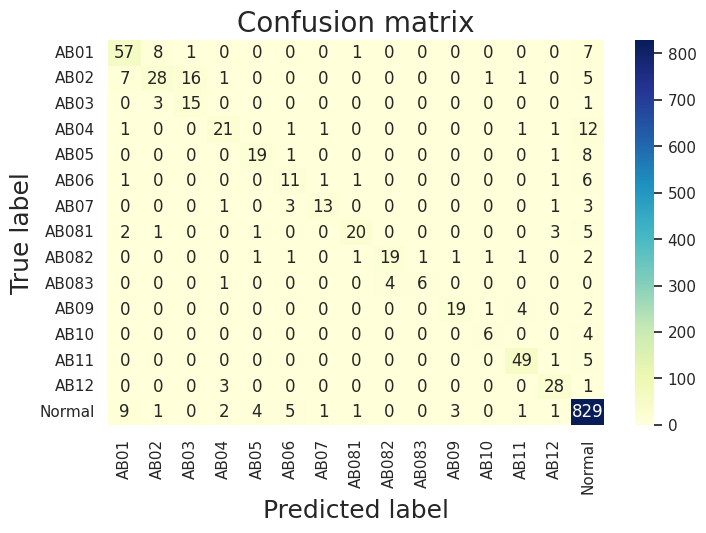

In [14]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)

#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)
ax.set_xlabel('Predicted label',fontsize=18)

In [15]:
# act= p1['Sub_class_New'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
act= data_train['Sub_class_New'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
pred = data_train['category'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 93.21646341463415%
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       857
           1       0.93      0.87      0.90       455

    accuracy                           0.93      1312
   macro avg       0.93      0.92      0.92      1312
weighted avg       0.93      0.93      0.93      1312



829 28 61 394


Text(66.25, 0.5, 'True label')

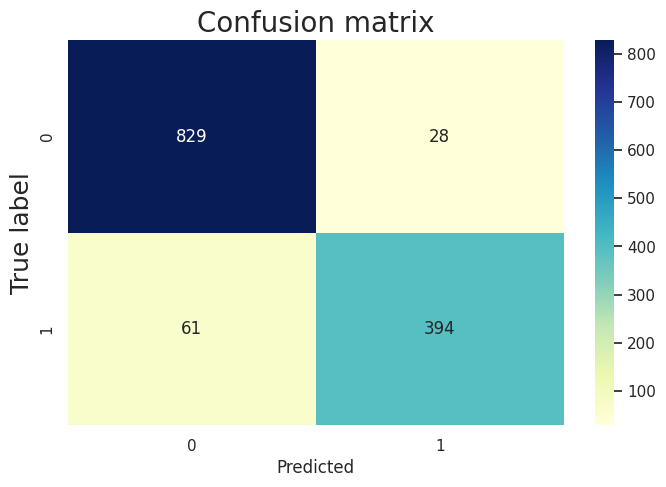

In [16]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)
TN, FP, FN, TP = confusion_matrix(act, pred).ravel()
print(TN, FP, FN, TP)
#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)

In [17]:
Sub_class_New = list(set(dataframe['Sub_class_New']))

for i in range(len(Sub_class_New)):
    df = dataframe[dataframe['Sub_class_New'] == Sub_class_New[i]]
    
    act = df['Sub_class_New'].array
    pred = df['category'].array

    cmat = confusion_matrix(act, pred)
    print('######', Sub_class_New[i])
#     print(cmat)
#     print(classification_report(act, pred))
    
    print('classifier accuracy = {}% \n'.format((np.trace(cmat))/(np.sum(cmat))))

###### AB09
classifier accuracy = 0.7307692307692307% 

###### AB081
classifier accuracy = 0.625% 

###### AB07
classifier accuracy = 0.6190476190476191% 

###### AB083
classifier accuracy = 0.5454545454545454% 

###### AB11
classifier accuracy = 0.8909090909090909% 

###### AB12
classifier accuracy = 0.875% 

###### AB06
classifier accuracy = 0.5238095238095238% 

###### AB04
classifier accuracy = 0.5526315789473685% 

###### AB01
classifier accuracy = 0.7702702702702703% 

###### AB082
classifier accuracy = 0.6785714285714286% 

###### AB03
classifier accuracy = 0.7894736842105263% 

###### AB10
classifier accuracy = 0.6% 

###### AB02
classifier accuracy = 0.4745762711864407% 

###### AB05
classifier accuracy = 0.6551724137931034% 

###### Normal
classifier accuracy = 0.9673278879813302% 



-----------

-------

# Exclude Normal classes

In [18]:
dataframe0_ = dataframe[(dataframe["Sub_class_New"]!="Normal") & (dataframe['category']!="Normal")].reset_index(drop=True)
print(dataframe0_.shape)
dataframe0_

(394, 29)


,Unnamed: 0,Case,Abs Position,Sub Position,Class,Path Full,Path Crop,Views,fold,15AB,...,Sub_class_New,tag_AjNit,tag_AjWan,Test150,Spilt,Sub_Position_New,filename,Sub_Position_Label,category,Prob
0,111,40,P1,P1,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P1,AB01 P1 C040.JPG,P1,AB02,1.000000
1,112,40,P2,P2,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P2,AB01 P2 C040.JPG,P2,AB01,1.000000
2,113,40,P4,P41,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P4,AB01 P4-1 C040.JPG,P4,AB01,0.999390
3,114,40,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P6,AB01 P5-1 C040.JPG,P6,AB02,0.999999
4,115,40,P3,P31,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P3,AB01 P3-1 C040.JPG,P3,AB02,0.999999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
389,2247,301,P7,P72,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,FP-D,1,RenalCyst,...,AB11,NaN,NaN,False,Test,P12,FP D P7-2 Case 143.JPG.png,P12,AB11,1.000000
390,2253,300,P7,P72,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,FP-D,1,Renalstones,...,AB11,NaN,NaN,False,Test,P12,FP D P7-2 Case 142.JPG.png,P12,AB11,1.000000
391,2265,361,P7,P72,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,FP-D,1,Hydronephrosis,...,AB11,Easy,Hard,False,Test,P12,FP D P7-2 Case 203.JPG.png,P12,AB11,1.000000
392,2269,343,P7,P72,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,FP-D,2,Hydronephrosis,...,AB11,NaN,NaN,False,Test,P12,FP D P7-2 Case 185.JPG.png,P12,AB11,1.000000


In [19]:
data_train = dataframe0_
#เช็คคลาสใน Predicted
pred_class = set(data_train['category'])
print('Predicted : ',len(pred_class))
print(pred_class)
#เช็คคลาสใน Actual
classe = set(data_train['Sub_class_New'])
print('Actual : ',len(classe))
print(classe)

Predicted :  14
{'AB09', 'AB081', 'AB07', 'AB083', 'AB11', 'AB12', 'AB06', 'AB04', 'AB01', 'AB082', 'AB03', 'AB10', 'AB02', 'AB05'}
Actual :  14
{'AB09', 'AB081', 'AB07', 'AB083', 'AB11', 'AB12', 'AB06', 'AB04', 'AB01', 'AB082', 'AB03', 'AB10', 'AB02', 'AB05'}


In [20]:
import numpy as np
from sklearn.metrics import confusion_matrix

act = data_train['Sub_class_New'].array
pred = data_train['category'].array

cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 78.93401015228426%
              precision    recall  f1-score   support

        AB01       0.84      0.85      0.84        67
        AB02       0.70      0.52      0.60        54
        AB03       0.47      0.83      0.60        18
        AB04       0.78      0.81      0.79        26
        AB05       0.90      0.90      0.90        21
        AB06       0.65      0.73      0.69        15
        AB07       0.87      0.72      0.79        18
       AB081       0.87      0.74      0.80        27
       AB082       0.83      0.73      0.78        26
       AB083       0.86      0.55      0.67        11
        AB09       0.95      0.79      0.86        24
        AB10       0.67      1.00      0.80         6
        AB11       0.88      0.98      0.92        50
        AB12       0.78      0.90      0.84        31

    accuracy                           0.79       394
   macro avg       0.79      0.79      0.78       394
weighted avg       0.80      0.79      

Text(0.5, 21.249999999999993, 'Predicted label')

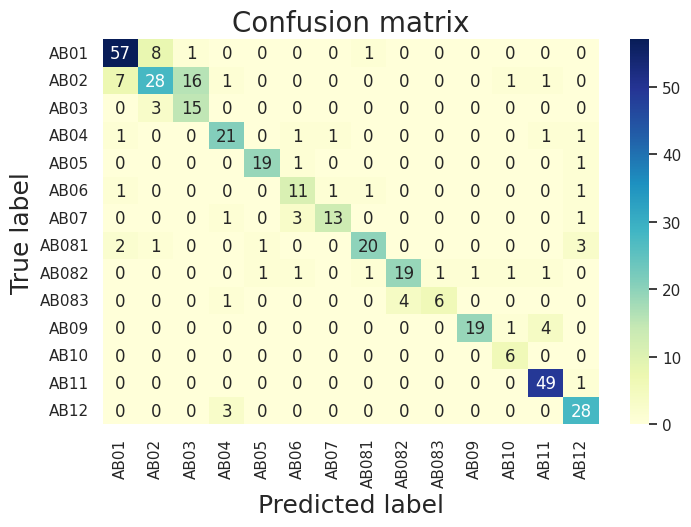

In [21]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)

#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)
ax.set_xlabel('Predicted label',fontsize=18)